In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Add src to path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from simulation import MarkovSwitchingDGP, RegimeParams, LucasShift, apply_lucas_shift, simulate_pre_post_break
from simulation.lucas_shift import MILD_SHIFT, SEVERE_SHIFT, concatenate_periods
from evaluation.visualization import (
    plot_simulated_series,
    plot_regime_transition_heatmap,
    save_figure,
)

sns.set_theme(style='whitegrid', context='notebook')
FIGURES_DIR = PROJECT_ROOT / 'analyses' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print('Setup complete.')

Setup complete.


In [2]:
dgp = MarkovSwitchingDGP(seed=42)
print(dgp)
print()
print('Transition matrix:')
print(dgp.transition)
print()
print('Stationary distribution:', dgp.stationary_distribution.round(4))

MarkovSwitchingDGP([recession(mu=-0.4, phi=0.7, sigma=1.8), expansion(mu=0.8, phi=0.35, sigma=0.7)], seed=42)

Transition matrix:
[[0.9  0.1 ]
 [0.15 0.85]]

Stationary distribution: [0.6 0.4]


In [3]:
df = dgp.simulate(n_obs=600)
print(f'Simulated {len(df)} observations after dropping NaN warm-up rows.')
print(df.head())

Simulated 581 observations after dropping NaN warm-up rows.
          y  regime regime_label    y_lag1    y_lag2  roll_mean_5  roll_std_5  \
0 -3.849349       0    recession -3.838367 -1.617775    -1.112247    2.906884   
1 -4.031603       0    recession -3.849349 -3.838367    -2.165878    2.795308   
2 -1.759440       0    recession -4.031603 -3.849349    -3.019307    1.218209   
3  0.353358       1    expansion -1.759440 -4.031603    -2.625080    1.908509   
4 -0.318798       1    expansion  0.353358 -1.759440    -1.921166    1.996186   

   roll_mean_20  roll_std_20    exog_0    exog_1    exog_2  
0      0.267109     2.137033  1.560485 -0.725698 -1.559839  
1      0.003990     2.327603 -1.628000 -0.727305 -0.841910  
2     -0.189199     2.304330 -1.326533 -0.548072 -0.583298  
3     -0.239519     2.279580  2.284919  0.236529  0.155792  
4     -0.331975     2.241195 -0.258281  0.356988  1.388703  


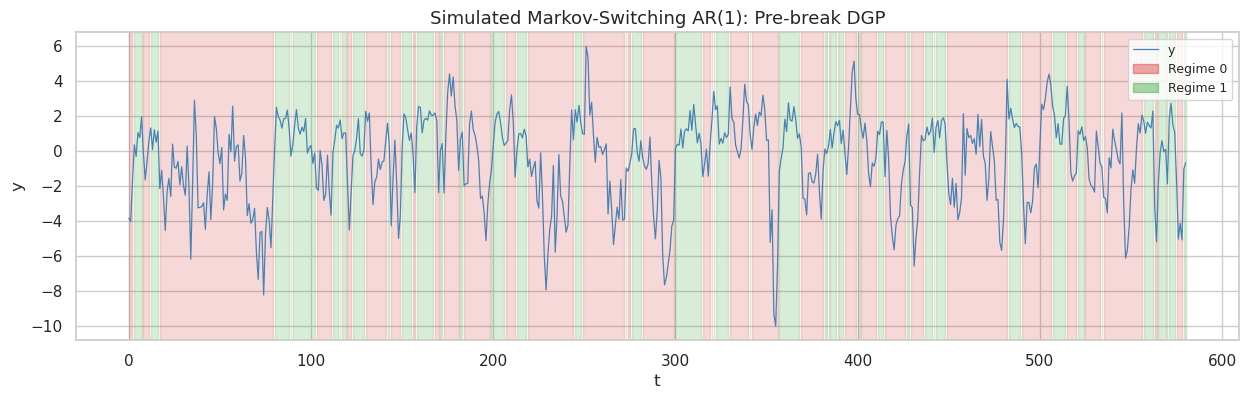

In [4]:
fig, ax = plt.subplots(figsize=(15, 4))
plot_simulated_series(df, title='Simulated Markov-Switching AR(1): Pre-break DGP', ax=ax)
save_figure(fig, '01_simulated_series')
plt.show()

In [5]:
print('Regime counts and proportions:')
print(df['regime_label'].value_counts())
print()
print('Descriptive statistics by regime:')
print(df.groupby('regime_label')['y'].agg(['mean', 'std', 'min', 'max']).round(4))

Regime counts and proportions:
regime_label
recession    386
expansion    195
Name: count, dtype: int64

Descriptive statistics by regime:
                mean     std      min     max
regime_label                                 
expansion     1.0706  0.8815  -1.8503  2.7535
recession    -1.2728  2.6267 -10.0334  5.9868


In [6]:
# Regime duration analysis
regime_seq = df['regime'].to_numpy()
durations = {0: [], 1: []}
count = 1
for i in range(1, len(regime_seq)):
    if regime_seq[i] == regime_seq[i - 1]:
        count += 1
    else:
        durations[regime_seq[i - 1]].append(count)
        count = 1
durations[regime_seq[-1]].append(count)

print('Regime duration summary:')
for reg, label in enumerate(['recession', 'expansion']):
    d = durations[reg]
    print(f'  {label}: mean={np.mean(d):.1f}, median={np.median(d):.1f}, max={max(d)}')

Regime duration summary:
  recession: mean=10.2, median=6.5, max=63
  expansion: mean=5.1, median=4.5, max=15


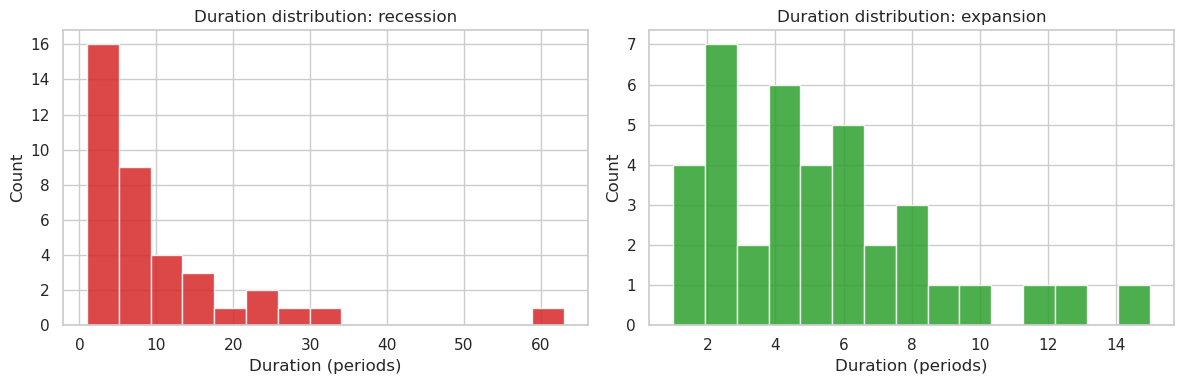

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for reg, (label, color) in enumerate(zip(['recession', 'expansion'], ['#d62728', '#2ca02c'])):
    axes[reg].hist(durations[reg], bins=15, color=color, edgecolor='white', alpha=0.85)
    axes[reg].set_title(f'Duration distribution: {label}')
    axes[reg].set_xlabel('Duration (periods)')
    axes[reg].set_ylabel('Count')
plt.tight_layout()
save_figure(fig, '01_regime_durations')
plt.show()

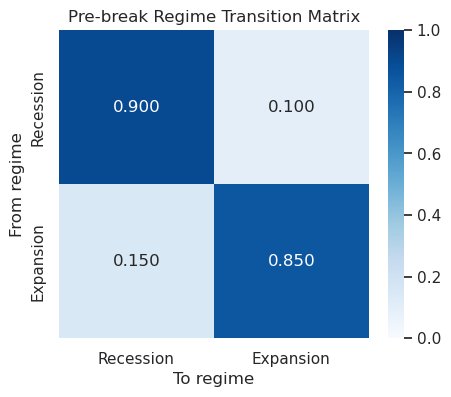

In [8]:
ax = plot_regime_transition_heatmap(
    dgp.transition,
    regime_labels=['Recession', 'Expansion'],
    title='Pre-break Regime Transition Matrix',
)
save_figure(ax.get_figure(), '01_transition_matrix_pre')
plt.show()

In [9]:
# Show the parameter changes
post_dgp = apply_lucas_shift(dgp, MILD_SHIFT)

print('Parameter comparison: Pre-break vs Post-break (Mild shift)')
print(f'{"Regime":<15} {"param":<10} {"pre":<10} {"post":<10} {"delta":<10}')
print('-' * 55)
for i, (pre_r, post_r) in enumerate(zip(dgp.regimes, post_dgp.regimes)):
    for param in ['mu', 'phi', 'sigma']:
        pre_val = getattr(pre_r, param)
        post_val = getattr(post_r, param)
        print(f'{pre_r.label:<15} {param:<10} {pre_val:<10.3f} {post_val:<10.3f} {post_val - pre_val:<10.3f}')
print()
print('Pre-break transition matrix:')
print(dgp.transition)
print('Post-break transition matrix:')
print(post_dgp.transition)

Parameter comparison: Pre-break vs Post-break (Mild shift)
Regime          param      pre        post       delta     
-------------------------------------------------------
recession       mu         -0.400     -1.200     -0.800    
recession       phi        0.700      0.800      0.100     
recession       sigma      1.800      2.500      0.700     
expansion       mu         0.800      0.400      -0.400    
expansion       phi        0.350      0.350      0.000     
expansion       sigma      0.700      0.700      0.000     

Pre-break transition matrix:
[[0.9  0.1 ]
 [0.15 0.85]]
Post-break transition matrix:
[[0.93 0.07]
 [0.2  0.8 ]]


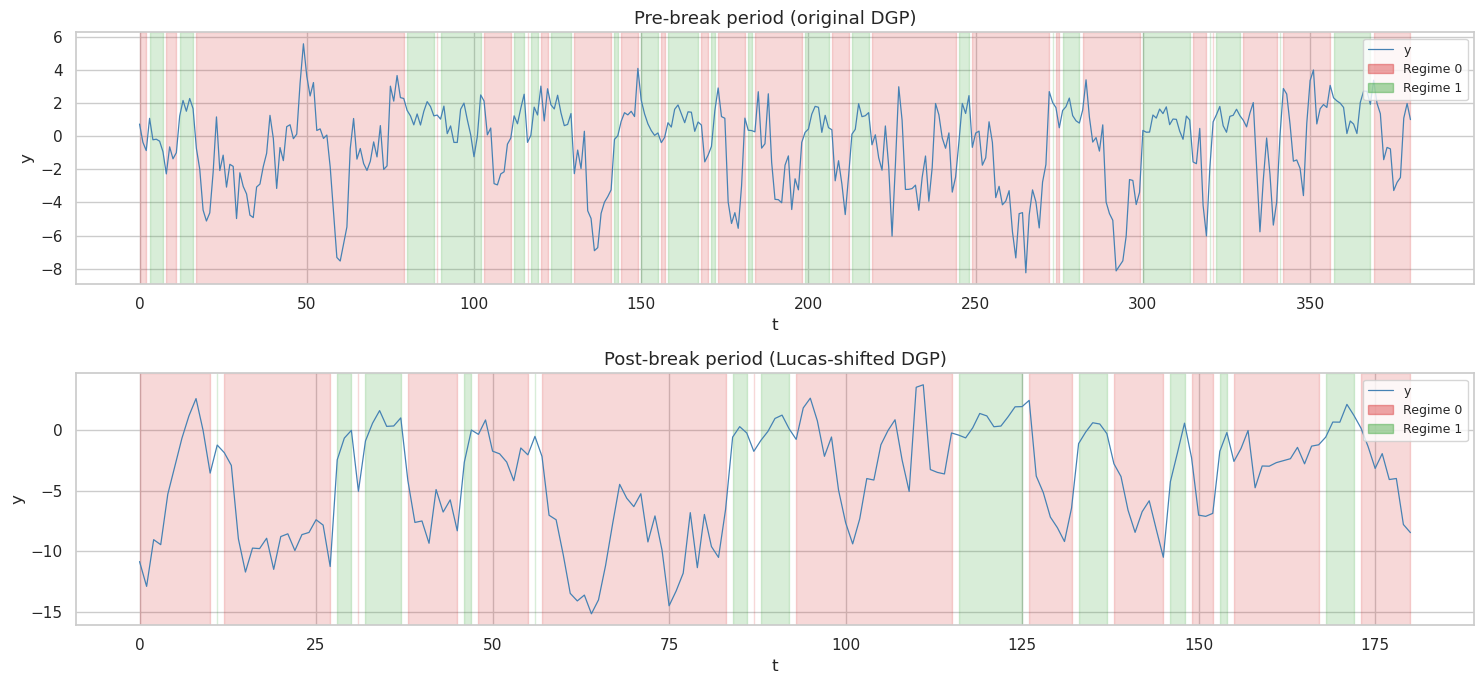

In [10]:
df_pre, df_post, post_dgp_used = simulate_pre_post_break(
    dgp, MILD_SHIFT, n_pre=400, n_post=200
)
df_full = concatenate_periods(df_pre, df_post)

fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=False)
plot_simulated_series(df_pre, title='Pre-break period (original DGP)', ax=axes[0])
plot_simulated_series(df_post, title='Post-break period (Lucas-shifted DGP)', ax=axes[1])
plt.tight_layout()
save_figure(fig, '01_pre_vs_post_break')
plt.show()

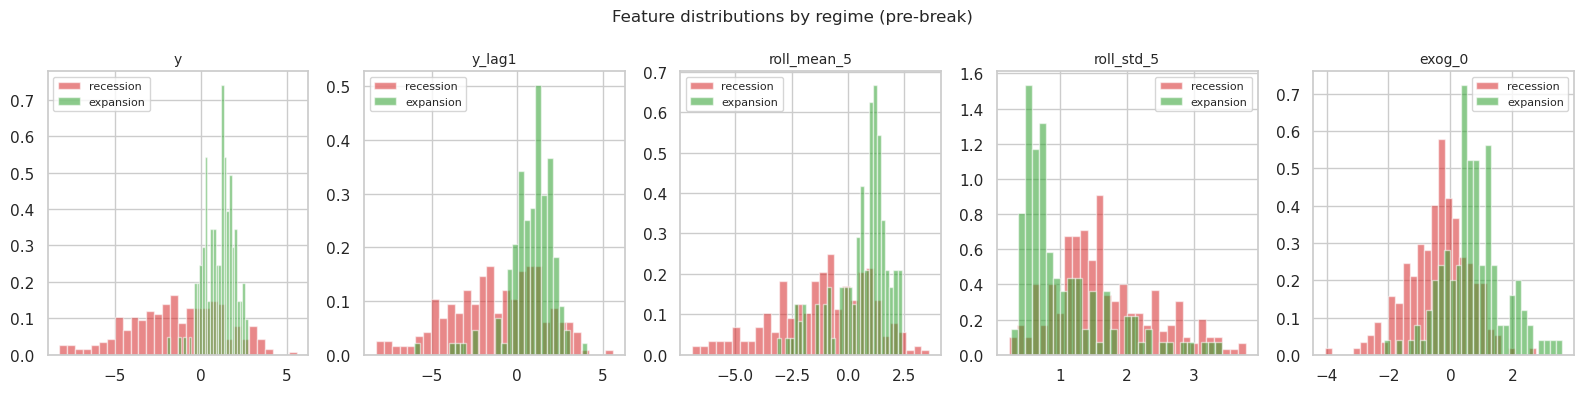

In [11]:
feature_cols = ['y', 'y_lag1', 'roll_mean_5', 'roll_std_5', 'exog_0']
fig, axes = plt.subplots(1, len(feature_cols), figsize=(16, 4))

for ax, col in zip(axes, feature_cols):
    for reg, (label, color) in enumerate(zip(['recession', 'expansion'], ['#d62728', '#2ca02c'])):
        data = df_pre[df_pre['regime'] == reg][col]
        ax.hist(data, bins=30, alpha=0.55, color=color, label=label, density=True)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
    ax.legend(fontsize=8)

fig.suptitle('Feature distributions by regime (pre-break)', fontsize=12)
plt.tight_layout()
save_figure(fig, '01_feature_distributions')
plt.show()

In [12]:
from pathlib import Path
data_dir = PROJECT_ROOT / 'data' / 'simulated'
data_dir.mkdir(parents=True, exist_ok=True)

df_pre.to_parquet(data_dir / 'pre_break.parquet', index=False)
df_post.to_parquet(data_dir / 'post_break.parquet', index=False)
df_full.to_parquet(data_dir / 'full_series.parquet', index=False)

print('Saved:')
for f in sorted(data_dir.glob('*.parquet')):
    print(f'  {f.name}  ({f.stat().st_size / 1024:.1f} KB)')

Saved:
  full_series.parquet  (62.8 KB)
  post_break.parquet  (23.8 KB)
  pre_break.parquet  (41.9 KB)
